# Code for Ch 2: Quantum Algorithms
This Jupyter notebook contains Qiskit code used for Chapter 2 of my tutorial on Quantum Machine Learning (QML), which is based on material from the 2021 Qiskit Summer School on QML and the online Qiskit textbook.

NB: it's worth noting, that the code here has been created with LLM assistance and by referring to the online Qiskit textbook

In [22]:
# Boilerplate to run 
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt 
plt.style.use('intro_to_qml_figure_style.mpltstyle') # This style sheet is in use.
 
import warnings 
warnings.filterwarnings( # Filter out the specific tight_layout warning generated by Jupyter/Matplotlib 3D plots
    "ignore", 
    category=UserWarning, 
    message="This figure includes Axes that are not compatible with tight_layout"
)

from qiskit.visualization import plot_bloch_vector
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display
import numpy as np

figure_directory = 'Figures/Ch2_Quantum_Algorithms_Figures/'

# Simple Demonstration of Quantum Effects
## Quantum Teleportation

The Qiskit implementation here and for superdense encording is based on implementations from the following <a href="https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation">Qiskit learning material</a>.

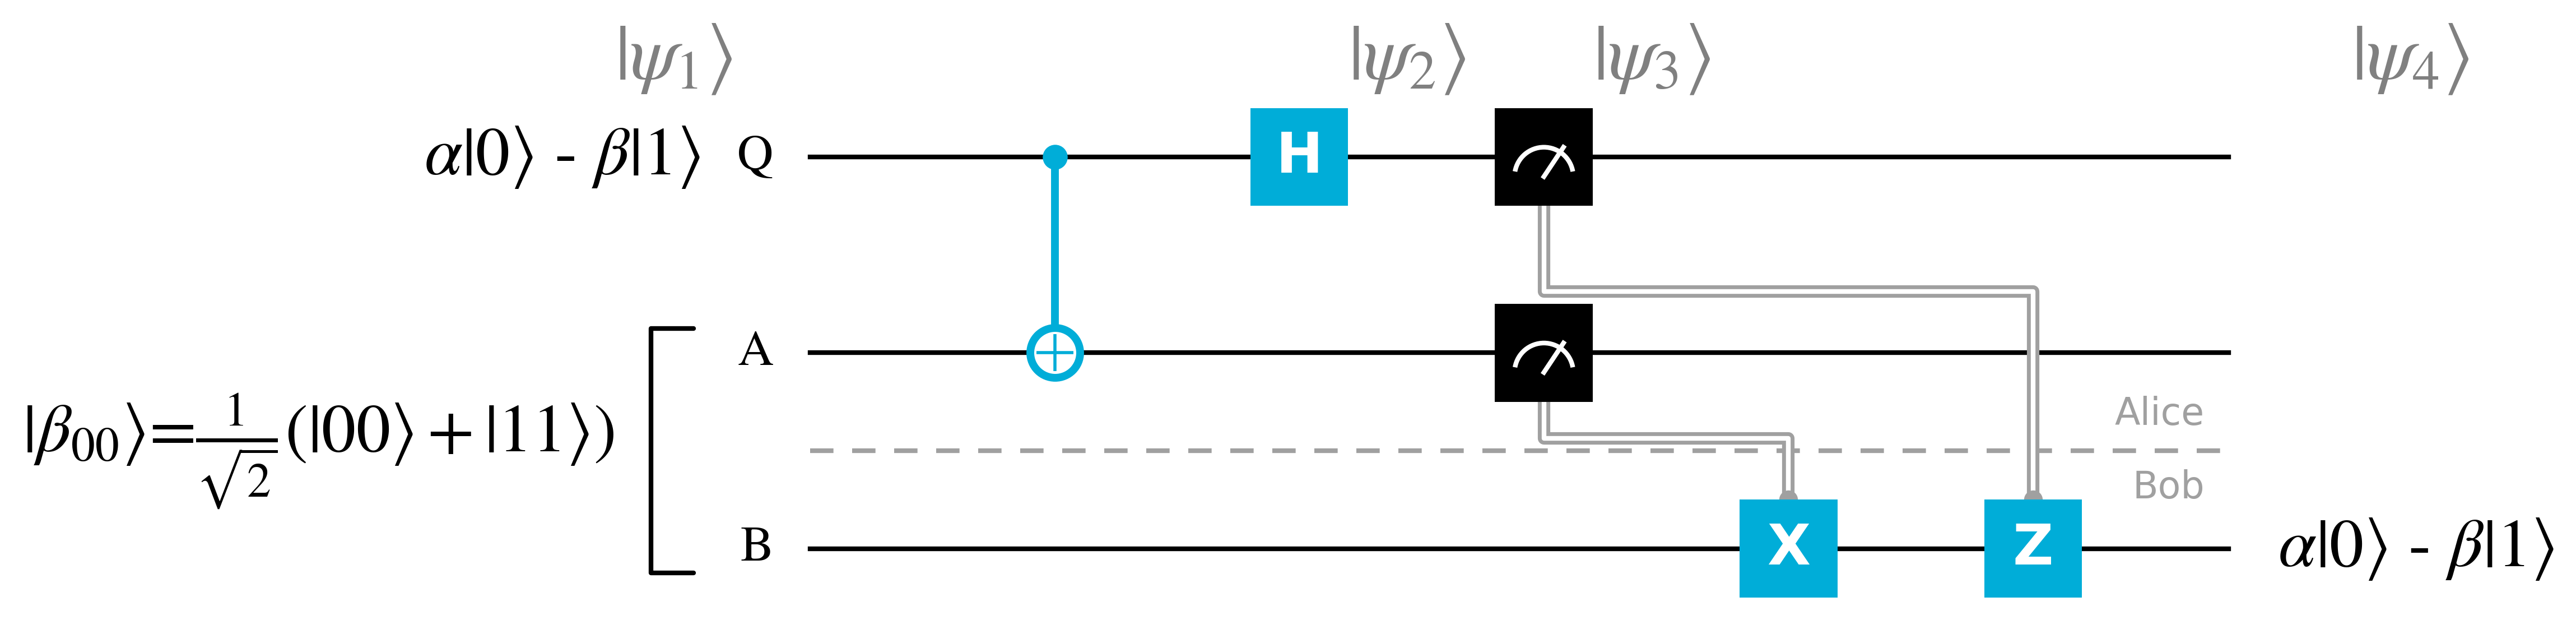

In [69]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Force Matplotlib to use STIX for all math text natively
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_teleportation_mpl(filename):
    # Set high resolution and canvas size
    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=400)
    ax.set_xlim(40, 750)
    ax.set_ylim(280, 60) # Inverted Y-axis so y=100 is at the top
    ax.axis('off') # Hide axes
    
    # === ADD THIS LINE TO FIX THE STRETCHING ===
    ax.set_aspect('equal') # Forces perfect square units
    # ============================================

    # --- Constants & Layout ---
    WIRE_Q, WIRE_A, WIRE_B = 100, 180, 260
    START_X, END_X = 120, 700
    BLUE = '#00ADD8'  # Rich cyan/blue matching the previous image
    BLACK = 'black'
    GREY = '#A0A0A0'

    # ==========================================
    # 2. DRAW WIRES & DIVIDER
    # ==========================================
    for y in [WIRE_Q, WIRE_A, WIRE_B]:
        ax.plot([START_X, END_X], [y, y], color=BLACK, lw=1.5, zorder=1)

    # Dashed dividing line
    ax.plot([START_X, END_X], [220, 220], color=GREY, lw=1.5, linestyle='--', dashes=(5, 4), zorder=1)
    ax.text(END_X - 10, 205, "Alice", color=GREY, fontsize=12, ha='right', va='center', fontfamily='sans-serif')
    ax.text(END_X - 10, 235, "Bob", color=GREY, fontsize=12, ha='right', va='center', fontfamily='sans-serif')

    # ==========================================
    # 3. LABELS & KETS (Full LaTeX Support!)
    # ==========================================
    text_opts = {'fontsize': 16, 'va': 'center'}
    ax.text(START_X - 15, WIRE_Q, "Q", ha='right', **text_opts)
    ax.text(START_X - 15, WIRE_A, "A", ha='right', **text_opts)
    ax.text(START_X - 15, WIRE_B, "B", ha='right', **text_opts)

    # Because of Matplotlib, we can use pure LaTeX strings now!
    ax.text(START_X - 45, WIRE_Q, r"$\alpha|0\rangle$ - $\beta|1\rangle$", ha='right', fontsize=22, va='center')
    ax.text(START_X - 80, (WIRE_A + WIRE_B)/2, r"$|\beta_{00}\rangle$=$\frac{1}{\sqrt{2}}(|00\rangle +|11\rangle)$", ha='right', fontsize=22, va='center')
    ax.text(END_X + 20, WIRE_B, r"$\alpha|0\rangle$ - $\beta|1\rangle$", ha='left', fontsize=22, va='center')

    # Draw curly bracket using Matplotlib annotations
    ax.annotate('', xy=(START_X - 45, WIRE_A - 10), xytext=(START_X - 45, WIRE_B + 10),
                arrowprops=dict(arrowstyle='-', connectionstyle='bar,fraction=-0.2', lw=1.5))

    # ==========================================
    # 4. HELPER FUNCTIONS FOR GATES
    # ==========================================
    def draw_gate(x, y, text):
        rect = patches.Rectangle((x-20, y-20), 40, 40, facecolor=BLUE, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=18, fontweight='bold', ha='center', va='center', zorder=4, fontfamily='sans-serif')

    def draw_meter(x, y):
        rect = patches.Rectangle((x-20, y-20), 40, 40, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y+8), 24, 24, theta1=190, theta2=350, color='white', lw=1.5, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x+8], [y+8, y-4], color='white', lw=1.5, zorder=4)

    # ==========================================
    # 5. GATES & MEASUREMENTS
    # ==========================================
    # CNOT
    cnot_x = 220
    ax.plot([cnot_x, cnot_x], [WIRE_Q, WIRE_A], color=BLUE, lw=2.5, zorder=2)
    ax.plot(cnot_x, WIRE_Q, marker='o', color=BLUE, markersize=7, zorder=3) # Control
    ax.plot(cnot_x, WIRE_A, marker='o', color='white', markeredgecolor=BLUE, markeredgewidth=2.5, markersize=16, zorder=3) # Target
    ax.plot(cnot_x, WIRE_A, marker='+', color=BLUE, markersize=12, zorder=4) # Cross

    draw_gate(320, WIRE_Q, "H")
    meter_x = 420
    draw_meter(meter_x, WIRE_Q)
    draw_meter(meter_x, WIRE_A)

    # ==========================================
    # 6. CLASSICAL COMMUNICATION LINES
    # ==========================================
    gate_x_pos, gate_z_pos = 520, 620

    # Lower line (A to X)
    x_lower = [meter_x, meter_x, gate_x_pos, gate_x_pos]
    y_lower = [WIRE_A + 20, WIRE_A + 35, WIRE_A + 35, WIRE_B - 20]
    ax.plot(x_lower, y_lower, color=GREY, lw=4, zorder=1)
    ax.plot(x_lower, y_lower, color='white', lw=1.5, zorder=2) # Creates the "double line" look

    # Upper line (Q to Z)
    x_upper = [meter_x, meter_x, gate_z_pos, gate_z_pos]
    y_upper = [WIRE_Q + 20, WIRE_A - 25, WIRE_A - 25, WIRE_B - 20]
    ax.plot(x_upper, y_upper, color=GREY, lw=4, zorder=1)
    ax.plot(x_upper, y_upper, color='white', lw=1.5, zorder=2)

    # Connection dots on classical wires
    ax.plot([gate_x_pos, gate_z_pos], [WIRE_B - 20, WIRE_B - 20], marker='o', color=GREY, markersize=5, lw=0, zorder=3)

    # Conditional Gates
    draw_gate(gate_x_pos, WIRE_B, "X")
    draw_gate(gate_z_pos, WIRE_B, "Z")

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
  
    ax.text(x_min + 0, y_max , r'$|\psi_1\rangle$', color='gray', **font_style)
    ax.text(x_min + 300, y_max , r'$|\psi_2\rangle$', color='gray', **font_style)
    ax.text(x_min + 400, y_max , r'$|\psi_3\rangle$', color='gray', **font_style)
    ax.text(x_max, y_max , r'$|\psi_4\rangle$', color='gray', **font_style)

    plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)
    #print(f"Success! Perfect LaTeX diagram saved to {filename}")

draw_teleportation_mpl(figure_directory+'quantum_teleportation_sketch.png')

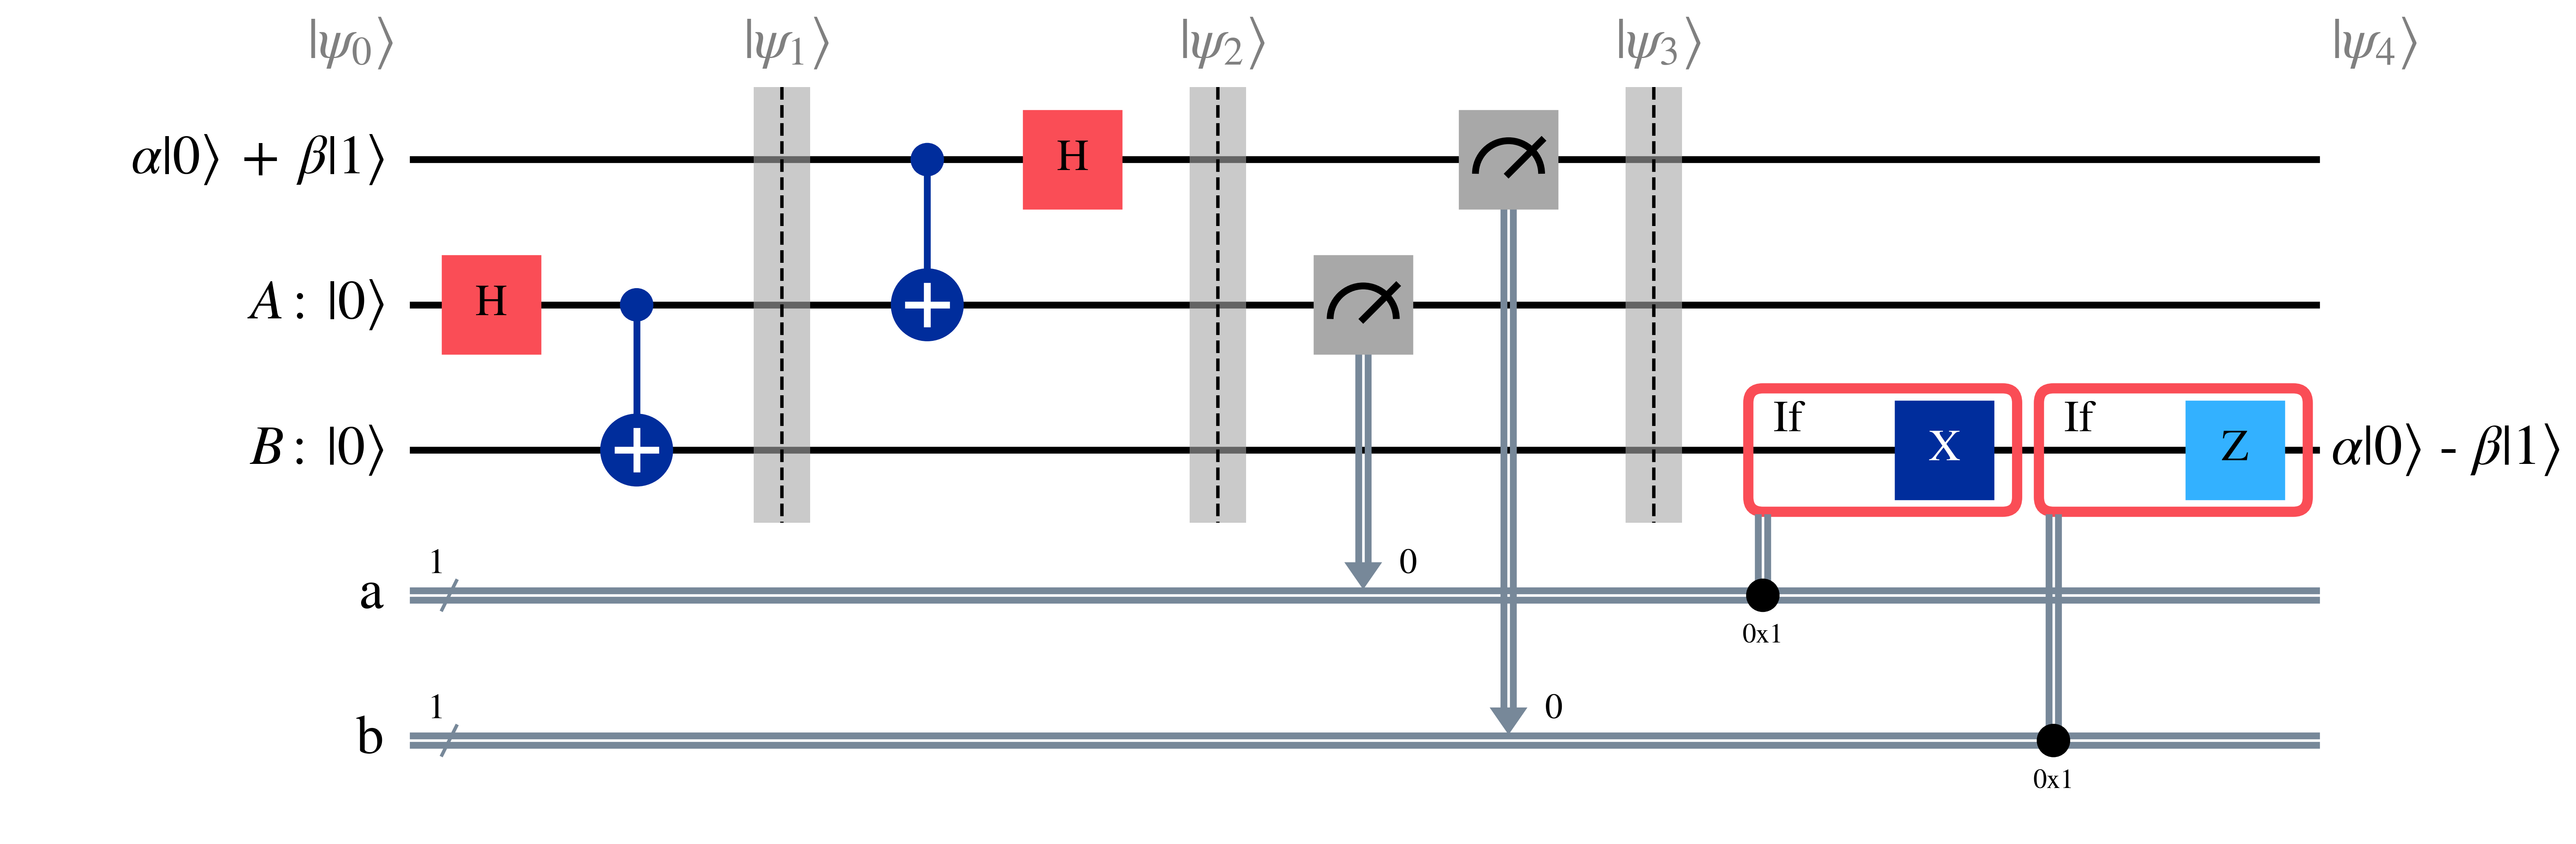

In [65]:
# Note, the folowing is based on code from https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation
qubit = QuantumRegister(1, "α|0⟩ + β|1⟩")
ebit0 = QuantumRegister(1, "A: |0⟩")
ebit1 = QuantumRegister(1, "B: |0⟩")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

#display(protocol.draw(output="mpl"))

fig_qc = protocol.draw(output='mpl', scale =1.5)#, initial_state=False)
ax = fig_qc.axes[0]
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.set_xlim(x_min, x_max + 1.5)
ax.set_ylim(y_min , y_max + 0.1)

font_style = {'fontsize': 25, 'verticalalignment': 'center'}
ax.text(x_min+2, y_max , r'$|\psi_0\rangle$', color='gray', **font_style)
ax.text(x_min + 5, y_max , r'$|\psi_1\rangle$', color='gray', **font_style)
ax.text(x_min + 8, y_max , r'$|\psi_2\rangle$', color='gray', **font_style)
ax.text(x_min + 11, y_max , r'$|\psi_3\rangle$', color='gray', **font_style)
ax.text(x_max, y_max , r'$|\psi_4\rangle$', color='gray', **font_style)
ax.text(x_max, y_min+2.6, r"$\alpha|0\rangle$ - $\beta|1\rangle$", **font_style)

fig_qc.savefig(figure_directory+'quantum_teleportation_annotated_circuit.png', bbox_inches='tight')